In [2]:
# Zachary Katz
# zachary_katz@mines.edu
# 07 May 2025
# Gigi Albers

"""
Example notebook to stream and plot SWOT data

Revision History
v0.1 - 7 May 2025
    SWOT track over Bach ice shelf
v0.2 - 22 May 2025
    Removed Mosaic of Antarctica backdrop
"""

# Imports
%load_ext autoreload
%autoreload 2

import util.plotting_helpers as plothelp
import matplotlib.pyplot as plt
import earthaccess
import xarray as xr
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Transformer


# Setup earthaccess.
# Follows protocol in https://book.cryointhecloud.com/how_tos/background/earthdata.html
auth = earthaccess.login(strategy="netrc")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
print("Enter BEFORE SWOT granule details:")
results = earthaccess.search_data(
        short_name = "SWOT_L2_HR_Raster_D",
        granule_name= input("Granule name (e.g., SWOT_L2_HR_Raster_250m_UTM54U_N_x_x_x_...): "),
        temporal= (
            input("Start date (YYYY-MM-DD, e.g., 2025-06-02): "),
            input("End date (YYYY-MM-DD, same as start for single day): ")
        ),
)

print(f"Number of granules found: {len(results)}")
if len(results) == 0:
    print("No granules found! Check your search parameters.")
else:
    print("Granules found. Proceeding to open...")

print("\nEnter bounding box coordinates [min_lon, max_lon, min_lat, max_lat]:")

swot_ds_before = xr.open_dataset(earthaccess.open(results)[0], engine="h5netcdf")

print("Enter AFTER SWOT granule details:")
results = earthaccess.search_data(
        short_name = "SWOT_L2_HR_Raster_D",
        granule_name= input("Granule name (e.g., SWOT_L2_HR_Raster_250m_UTM54U_N_x_x_x_...): "),
        temporal= (
            input("Start date (YYYY-MM-DD, e.g., 2025-06-02): "),
            input("End date (YYYY-MM-DD, same as start for single day: ")
        ),
)

print(f"Number of granules found: {len(results)}")
if len(results) == 0:
    print("No granules found! Check your search parameters.")
else:
    print("Granules found. Proceeding to open...")

print("\nEnter bounding box coordinates [min_lon, max_lon, min_lat, max_lat]:")
bbox = [
    float(input("Min longitude: ")),
    float(input("Max longitude: ")),
    float(input("Min latitude: ")),
    float(input("Max latitude: "))
]

swot_ds_after = xr.open_dataset(earthaccess.open(results)[0], engine="h5netcdf")

Enter BEFORE SWOT granule details:


Granule name (e.g., SWOT_L2_HR_Raster_250m_UTM54U_N_x_x_x_...):  SWOT_L2_HR_Raster_250m_UTM43P_N_x_x_x_034_426_070F_20250623T230925_20250623T230944_PID0_01.nc
Start date (YYYY-MM-DD, e.g., 2025-06-02):  2025-06-23
End date (YYYY-MM-DD, same as start for single day):  2025-06-23


Number of granules found: 1
Granules found. Proceeding to open...

Enter bounding box coordinates [min_lon, max_lon, min_lat, max_lat]:


QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 710.54it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:01<00:00,  1.47s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 11848.32it/s]


Enter AFTER SWOT granule details:


Granule name (e.g., SWOT_L2_HR_Raster_250m_UTM54U_N_x_x_x_...):  SWOT_L2_HR_Raster_250m_UTM43P_N_x_x_x_032_426_070F_20250513T053914_20250513T053933_PID0_01.nc
Start date (YYYY-MM-DD, e.g., 2025-06-02):  2025-05-13
End date (YYYY-MM-DD, same as start for single day:  2025-05-13


Number of granules found: 1
Granules found. Proceeding to open...

Enter bounding box coordinates [min_lon, max_lon, min_lat, max_lat]:


Min longitude:  7.92941
Max longitude:  9.24555
Min latitude:  76.55275
Max latitude:  77.87044


QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 2326.29it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 18.75it/s]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 13706.88it/s]


Before Event (Format: Specific location, mm/dd/yyyy):  Cape of South India, 05/13/2025
After Event (Format: Specific location, mm/dd/yyyy):  Cape of South India, 06/23/2025
Main location:  India


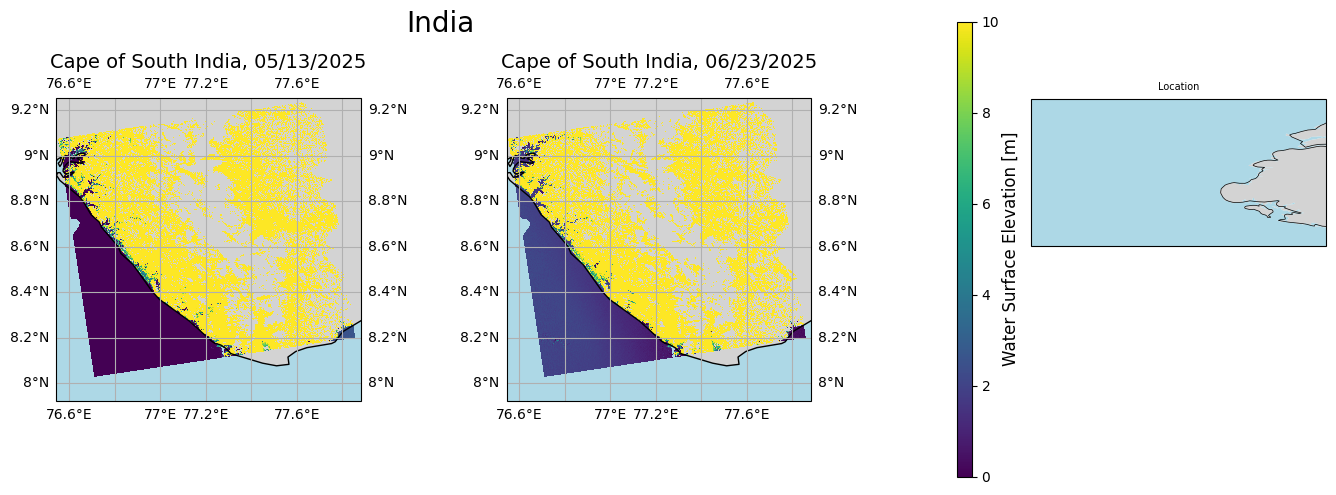

In [4]:
fig = plt.figure(figsize=(30/2.54, 15/2.54))  # Width, Height in inches (30cm wide, 15cm tall)
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.7)  # Two plots, one colorbar

# Create axes for the plots
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
cax = fig.add_subplot(gs[0, 2])  # Colorbar axis

# Function to plot SWOT data on a given axis
def plot_swot_data(ax, ds, title):
    # Get data
    wse = ds["wse"] + ds["height_cor_xover"]
    
    # Convert UTM to lat/lon
    utm_zone = ds.utm_zone_num
    utm_crs = ccrs.UTM(zone=utm_zone, southern_hemisphere=False)
    transformer = Transformer.from_crs(utm_crs, ccrs.PlateCarree(), always_xy=True)
    x_utm, y_utm = wse["x"].values, wse["y"].values
    X_utm, Y_utm = np.meshgrid(x_utm, y_utm)
    X_lon, Y_lat = transformer.transform(X_utm, Y_utm)
    
    # Plot data
    mesh = ax.pcolormesh(
        X_lon,
        Y_lat,
        wse.values,
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        vmin=0,
        vmax=10,
    )
    
    # Add map features
    ax.gridlines(draw_labels=True)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.coastlines(resolution='10m', linewidth=1)
    ax.set_title(title, fontsize=14)
    
    return mesh

# Plot both datasets
mesh1 = plot_swot_data(ax1, swot_ds_before, input("Before Event (Format: Specific location, mm/dd/yyyy): "))
mesh2 = plot_swot_data(ax2, swot_ds_after, input("After Event (Format: Specific location, mm/dd/yyyy): "))

# Add single colorbar
cbar = fig.colorbar(mesh1, cax=cax, orientation='vertical', location ='right', pad=0.5)
cbar.set_label(
    "Water Surface Elevation [m]",
    fontsize=12,
    labelpad=15,  # Space between colorbar and label
    ha='center',  # Horizontal alignment
    va='bottom',  # Vertical alignment
    rotation=90    # 0=horizontal, 90=vertical
)


fig.text(
    x=0.45,  # Left alignment (0=far left, 1=far right)
    y=0.90,   # Vertical position (1=top of figure)
    s=input("Main location: "),  # Your custom title text
    fontsize=20,
    color='black',
    va='top', # Vertical alignment
    ha='center'   # Horizontal alignment
)

def plot_small_inset(fig, position, bbox):
    ax_inset = fig.add_axes(position, projection=ccrs.PlateCarree())
    
    # Find a new wide set of longitudes and latitudes that clearly indicate where you are
    ax_inset.set_extent([45,55,70,75], crs=ccrs.PlateCarree()) #[longitude_min, longitude_max, latitude_min, latitude_max], [-20, 20, 0, 30]

                    
    # Add features
    ax_inset.add_feature(cfeature.LAND, facecolor='lightgray')
    ax_inset.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax_inset.coastlines(resolution='50m', linewidth=0.5)
    
    # Add red rectangle showing specific area 
    rect = plt.Rectangle(
    (bbox[1], bbox[0]), 
    bbox[2]-bbox[0], 
    bbox[3]-bbox[1],
    fill=False, color='red', linewidth=1,
    transform=ccrs.PlateCarree()
)
    ax_inset.add_patch(rect)
    
    ax_inset.set_title("Location", fontsize=7)
    return ax_inset

inset = plot_small_inset(
    fig=fig,
    position=[0.95, 0.5, 0.25, 0.25],  # [left, bottom, width, height]
    bbox= bbox #[3.35058, 6.26802, 4.6684, 7.57602]
)

plt.show()

In [8]:
swot_ds

<xarray.Dataset> Size: 85MB
Dimensions:                  (x: 659, y: 658)
Coordinates:
  * x                        (x) float64 5kB 5.37e+05 5.372e+05 ... 7.015e+05
  * y                        (y) float64 5kB 5.87e+06 5.87e+06 ... 6.034e+06
Data variables: (12/39)
    crs                      object 8B ...
    longitude                (y, x) float64 3MB ...
    latitude                 (y, x) float64 3MB ...
    wse                      (y, x) float32 2MB ...
    wse_qual                 (y, x) float32 2MB ...
    wse_qual_bitwise         (y, x) float64 3MB ...
    ...                       ...
    load_tide_fes            (y, x) float32 2MB ...
    load_tide_got            (y, x) float32 2MB ...
    pole_tide                (y, x) float32 2MB ...
    model_dry_tropo_cor      (y, x) float32 2MB ...
    model_wet_tropo_cor      (y, x) float32 2MB ...
    iono_cor_gim_ka          (y, x) float32 2MB ...
Attributes: (12/49)
    Conventions:                   CF-1.7
    title:                         Level 2 KaRIn High Rate Raster Data Product
    source:                        Ka-band radar interferometer
    history:                       2025-06-06T02:59:43Z : Creation
    platform:                      SWOT
    references:                    V1.4.1
    ...                            ...
    mgrs_latitude_band:            U
    x_min:                         537000.0
    x_max:                         701500.0
    y_min:                         5869750.0
    y_max:                         6034000.0
    institution:                   CNES